<a href="https://colab.research.google.com/github/helenxu0624/musa-650-spring2026-Projects/blob/main/EuroStats/eurosat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EuroSAT Project
### Members: Katie Knox, Helen Xu, Ezra Rwakazooba
#### Submission date:  April 5th, 2026

In [ ]:
import zipfile
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from io import BytesIO

### 1. Data Loading, Processing, and Exploration

#### 1.1 Data Preparation

Visit the EuroSAT data description page and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

In [ ]:
ZIP_PATH = r"C:\Users\Ez\Downloads\EuroSAT_MS.zip"
EXTRACT_DIR = Path("eurosat_files/EuroSAT_MS")

# Extract zip if not already done
if not EXTRACT_DIR.exists():
    print("Extracting zip...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR.parent)
    print("Done.")
else:
    print("Already extracted.")

Extracting zip...
Done.


In [ ]:
# Build list of (file_path, label) pairs from folder names
samples = []
classes = sorted([d.name for d in EXTRACT_DIR.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(classes)}

for cls in classes:
    cls_dir = EXTRACT_DIR / cls
    for img_path in sorted(cls_dir.glob("*.tif")):
        samples.append((img_path, class_to_idx[cls]))

print(f"Classes ({len(classes)}): {classes}")
print(f"Total images: {len(samples)}")

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000


In [ ]:
from collections import Counter

label_counts = Counter(label for _, label in samples)
counts = [label_counts[class_to_idx[cls]] for cls in classes]
total = sum(counts)

for cls, idx in class_to_idx.items():
    class_pcts = np.round(label_counts[idx] / total * 100, 1)
    print(f"  {cls:25s}: {label_counts[idx]:,} images ({class_pcts}%)")

  AnnualCrop               : 3,000 images (11.1%)
  Forest                   : 3,000 images (11.1%)
  HerbaceousVegetation     : 3,000 images (11.1%)
  Highway                  : 2,500 images (9.3%)
  Industrial               : 2,500 images (9.3%)
  Pasture                  : 2,000 images (7.4%)
  PermanentCrop            : 2,500 images (9.3%)
  Residential              : 3,000 images (11.1%)
  River                    : 2,500 images (9.3%)
  SeaLake                  : 3,000 images (11.1%)


<font color='turquoise'>
The dataset has *27000* samples with good class balance.
AnnualCrop, Forest, HerbaceousVegetation, Residential and SeaLake all balance (3,000 samples, ~11.1%), while Highway, Industrial,  PermanentCrop and River   (2500 samples ~9.3%) and Pasture being the least class (2000 samples ~7.4%)
</font>


C:\Users\HP ENVY\AppData\Local\Temp\ipykernel_16960\2971806986.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=30, ha="right")


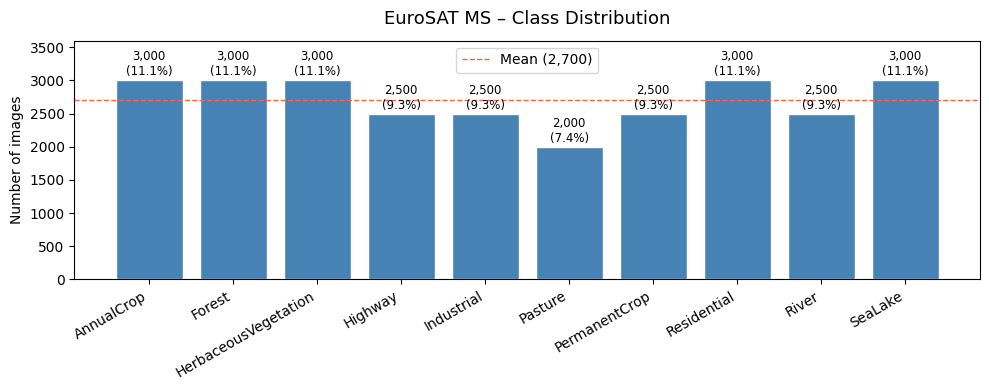

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(classes, counts, color="steelblue", edgecolor="white")

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}\n({count / total:.1%})",
        ha="center",
        va="bottom",
        fontsize=8.5,
    )

mean_count = total // len(classes)
ax.axhline(
    mean_count,
    color="tomato",
    linestyle="--",
    linewidth=1,
    label=f"Mean ({mean_count:,})",
)
ax.set_title("EuroSAT MS – Class Distribution", fontsize=13, pad=12)
ax.set_ylabel("Number of images")
ax.set_ylim(0, max(counts) * 1.2)
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

### Plotting one image from each class in a 2x5 grid.

In [ ]:
def load_image(path):
    """Load a multispectral GeoTIFF as a (bands, H, W) numpy array."""
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)  # shape: (13, 64, 64)

# Inspect a single image
img_path, label = samples[0]
img = load_image(img_path)
print(f"Image shape : {img.shape}  (bands, H, W)")
print(f"Label       : {label} ({classes[label]})")
print(f"Value range : {img.min():.0f} – {img.max():.0f}")

Image shape : (13, 64, 64)  (bands, H, W)
Label       : 0 (AnnualCrop)
Value range : 9 – 3490


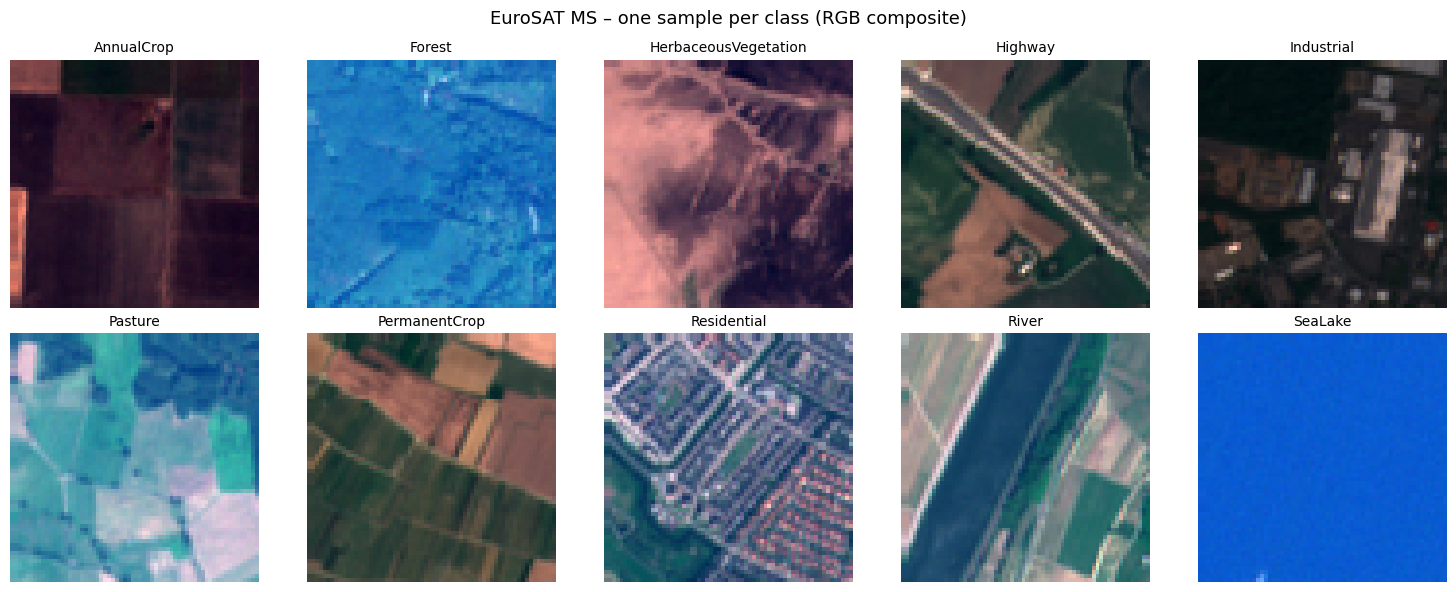

In [ ]:
# Sentinel-2 band reference
BAND_NAMES = [
    "B01 (Coastal)", "B02 (Blue)", "B03 (Green)", "B04 (Red)",
    "B05 (Red Edge 1)", "B06 (Red Edge 2)", "B07 (Red Edge 3)",
    "B08 (NIR)", "B08A (Narrow NIR)", "B09 (Water Vapor)",
    "B10 (SWIR Cirrus)", "B11 (SWIR 1)", "B12 (SWIR 2)"
]

# Display one sample per class using RGB (B04, B03, B02)
RED, GREEN, BLUE = 3, 2, 1  # band indices (0-based)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, cls in enumerate(classes):
    # Grab first sample of this class
    path, _ = next((s, l) for s, l in samples if classes[l] == cls)
    img = load_image(path)

    # Build RGB composite and normalise to [0, 1]
    rgb = np.stack([img[RED], img[GREEN], img[BLUE]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

    axes[i].imshow(rgb)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")

plt.suptitle("EuroSAT MS – one sample per class (RGB composite)", fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 Data Augmentation

Before splitting the data into training and testing sets or doing any preprocessing, apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset.

Indicate the augmentation approach(es) that you used and the total size of the new dataset.

Again, plot three random images and a histogram of the label distribution across the full dataset.

<font color='turquoise'> The data augmentation method we propose are the following;
<br>

<ol>
    <li> Rotating (0-180) degrees
    <li> Zoom
    <li> width shift
    <li> Height shift
</ol>
</font>

In [ ]:
from scipy.ndimage import rotate, shift
from scipy.ndimage import zoom as sp_zoom
from tqdm.notebook import tqdm

In [ ]:
def load_image(path: Path) -> np.ndarray:
    """Load a .tif or augmented .npy file as a (bands, H, W) float32 array."""
    path = Path(path)
    if path.suffix == ".npy":
        return np.load(path).astype(np.float32)
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)

In [ ]:
def augment_rotate(img: np.ndarray, angle: float = 30.0) -> np.ndarray:
    """Rotate image by angle degrees in the spatial (H, W) plane."""
    return rotate(img, angle, axes=(1, 2), reshape=False)


def augment_zoom(img: np.ndarray, factor: float = 1.2) -> np.ndarray:
    """Zoom in by factor and centre-crop back to the original spatial size."""
    _, h, w = img.shape
    zoomed = sp_zoom(img, [1.0, factor, factor])
    _, zh, zw = zoomed.shape
    ch, cw = (zh - h) // 2, (zw - w) // 2
    return zoomed[:, ch : ch + h, cw : cw + w]


def augment_width_shift(img: np.ndarray, shift_px: int = 8) -> np.ndarray:
    """Shift image horizontally by shift_px pixels."""
    return shift(img, [0, 0, shift_px])


def augment_height_shift(img: np.ndarray, shift_px: int = 8) -> np.ndarray:
    """Shift image vertically by shift_px pixels."""
    return shift(img, [0, shift_px, 0])

# for Size I will only use rotate and zoom, as the shifts cause too much blank space around the edges which is not ideal for a small 64x64 image. I will keep the shift functions in case I want to experiment with them later, but I will comment them out of the AUGMENTATIONS dict for now.
AUGMENTATIONS = {
    "rotate": augment_rotate,
    #"zoom": augment_zoom,
    #"width_shift": augment_width_shift,
    #"height_shift": augment_height_shift,
}

In [ ]:
AUG_DIR = Path("eurosat_files/augmented")
AUG_DIR.mkdir(parents=True, exist_ok=True)

for cls in classes:
    (AUG_DIR / cls).mkdir(exist_ok=True)

In [ ]:
aug_samples = []

for cls in tqdm(classes, desc="Augmenting"):
    idx = class_to_idx[cls]
    cls_paths = [p for p, l in samples if l == idx]

    for path in cls_paths:
        img = load_image(path)
        stem = Path(path).stem

        for aug_name, aug_fn in AUGMENTATIONS.items():
            out_path = AUG_DIR / cls / f"{stem}_{aug_name}.npy"
            if not out_path.exists():
                np.save(out_path, aug_fn(img))
            aug_samples.append((out_path, idx))
print(f"Augmented samples created: {len(aug_samples):,}")

Augmenting:   0%|          | 0/10 [00:00<?, ?it/s]

Augmented samples created: 27,000


In [ ]:
all_samples = samples + aug_samples

print(f"Original  : {len(samples):,}")
print(f"Augmented : {len(aug_samples):,}")
print(f"Total     : {len(all_samples):,}")

Original  : 27,000
Augmented : 27,000
Total     : 54,000


In [ ]:
all_label_counts = Counter(label for _, label in all_samples)
all_counts = [all_label_counts[class_to_idx[cls]] for cls in classes]
all_total = sum(all_counts)

for cls, idx in class_to_idx.items():
    pct = np.round(all_label_counts[idx] / all_total * 100, 1)
    print(f"  {cls:25s}: {all_label_counts[idx]:,} images ({pct}%)")

  AnnualCrop               : 6,000 images (11.1%)
  Forest                   : 6,000 images (11.1%)
  HerbaceousVegetation     : 6,000 images (11.1%)
  Highway                  : 5,000 images (9.3%)
  Industrial               : 5,000 images (9.3%)
  Pasture                  : 4,000 images (7.4%)
  PermanentCrop            : 5,000 images (9.3%)
  Residential              : 6,000 images (11.1%)
  River                    : 5,000 images (9.3%)
  SeaLake                  : 6,000 images (11.1%)


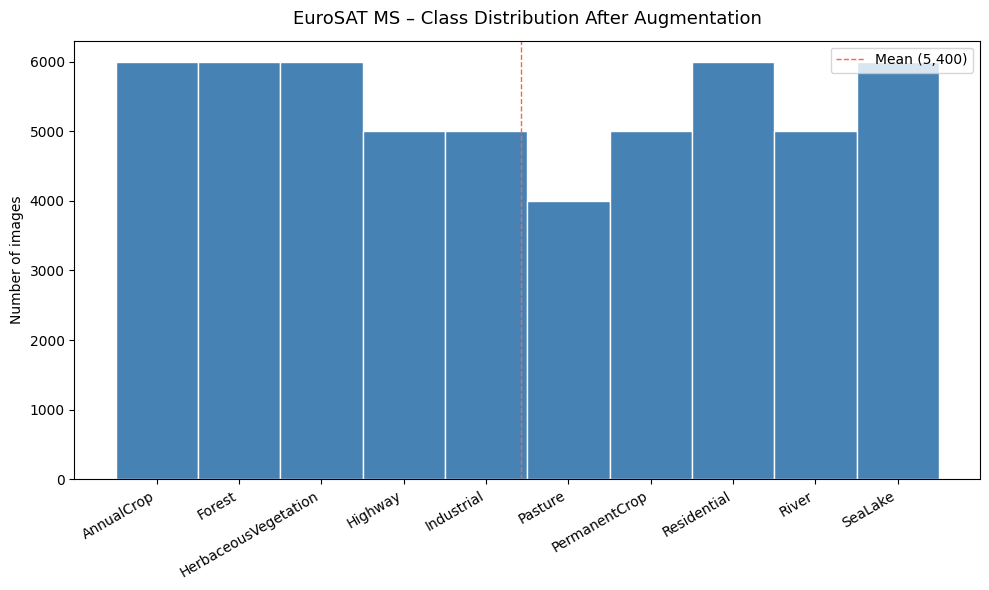

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

label_series = [label for _, label in all_samples]
ax.hist(
    label_series,
    bins=len(classes),
    range=(-0.5, len(classes) - 0.5),
    color="steelblue",
    edgecolor="white",
)

all_mean = all_total // len(classes)
ax.axvline(
    np.mean(label_series),
    color="tomato",
    linestyle="--",
    linewidth=1,
    label=f"Mean ({all_mean:,})",
)
ax.set_title("EuroSAT MS \u2013 Class Distribution After Augmentation", fontsize=13, pad=12)
ax.set_ylabel("Number of images")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

In [ ]:
import dask
from dask import delayed
from dask.diagnostics import ProgressBar
from sklearn.model_selection import train_test_split

In [ ]:
@delayed
def load_flat(path: Path) -> np.ndarray:
    """Load one image and flatten to a 1-D (bands × H × W) float32 array."""
    return load_image(path).flatten()


y = np.array([lbl for _, lbl in all_samples], dtype=np.int32)
lazy_rows = [load_flat(path) for path, _ in all_samples]

with ProgressBar():
    rows = dask.compute(*lazy_rows, scheduler="threads")

X = np.stack(rows).astype(np.float32)

print(f"X shape : {X.shape}  (n={X.shape[0]:,} samples, p={X.shape[1]:,} pixels)")
print(f"y shape : {y.shape}")
print(f"RAM     : {X.nbytes / 1e9:.1f} GB")

[########################################] | 100% Completed | 492.25 s
X shape : (54000, 53248)  (n=54,000 samples, p=53,248 pixels)
y shape : (54000,)
RAM     : 11.5 GB


In [ ]:
indices = np.arange(len(all_samples))

idx_train, idx_test, y_train, y_test = train_test_split(
    indices, y, test_size=0.4, stratify=y, random_state=42
)

X_train, X_test = X[idx_train], X[idx_test]

print(f"Train : X={X_train.shape},  y={y_train.shape}")
print(f"Test  : X={X_test.shape},   y={y_test.shape}")

Train : X=(32400, 53248),  y=(32400,)
Test  : X=(21600, 53248),   y=(21600,)


In [ ]:
# Reshape to (n, 13, 64, 64) to isolate visible RGB bands
n = X.shape[0]
X_cube = X.reshape(n, 13, 64, 64)

# Luminance-weighted grayscale from B04 (Red), B03 (Green), B02 (Blue)
R = X_cube[:, 3].reshape(n, -1)
G = X_cube[:, 2].reshape(n, -1)
B = X_cube[:, 1].reshape(n, -1)

X_gray = (0.2989 * R + 0.5870 * G + 0.1140 * B).astype(np.float32)

X_gray_train = X_gray[idx_train]
X_gray_test = X_gray[idx_test]

print(f"X_gray       : {X_gray.shape}  ({X_gray.nbytes / 1e9:.1f} GB)")
print(f"X_gray_train : {X_gray_train.shape}")
print(f"X_gray_test  : {X_gray_test.shape}")

X_gray       : (54000, 4096)  (0.9 GB)
X_gray_train : (32400, 4096)
X_gray_test  : (21600, 4096)
